Part A: Frequency Table with Cumulative Frequency [Marks: 5]
Create a frequency table for the Rating column using the following rating ranges (bins):
• 0–2, 2–4, 4–6, 6–8, 8–10
Your frequency table must include:
• Rating Range — the bin label (e.g., &#39;0–2&#39;, &#39;2–4&#39; …)
• Frequency — number of movies falling in that range
• Cumulative Frequency — running total of frequencies
Print the complete table in a readable format. For example:
Rating Range | Frequency | Cumulative Frequency
0 - 2 | 3 | 3
2 - 4 | 12 | 15
4 - 6 | 28 | 43
6 - 8 | 45 | 88
8 - 10 | 12 | 100

In [1]:
#load the dataset and import libraries 
#importing necessary libraries 

import pandas as pd 
import matplotlib.pyplot as plt 

In [2]:

#Load the file 
df = pd.read_csv("C:\\Users\\HP\\Desktop\\Lab Sample\\movie_ratings.csv")

In [ ]:
# Correct bins (must include 10)
bins = range(0,10,2)

# Get frequency
freq = pd.cut(df['Rating'], bins=bins).value_counts().sort_index()

# Get cumulative frequency
cumulative_freq = freq.cumsum()

# Convert interval labels to cleaner format
ranges = freq.index.astype(str)

# Print table
#I made is shorter for you gues to easily remember
print("Rating Range | Frequency | Cumulative Frequency")
print("-" * 55)

print("\n".join(
    f"{ranges[i]} | {freq.values[i]} | {cumulative_freq.values[i]}"
    for i in range(len(freq))
))

Rating Range | Frequency | Cumulative Frequency
-------------------------------------------------------
(0, 2] | 0 | 0
(2, 4] | 0 | 0
(4, 6] | 0 | 0
(6, 8] | 43 | 43


In [14]:
#now if we want to use the one in the file.
#extra 

# Correct bins (must include 10)
bins = range(0,11,2)

# Get frequency
freq = pd.cut(df['Rating'], bins=bins).value_counts().sort_index()

# Get cumulative frequency
cumulative_freq = freq.cumsum()

# Convert interval labels to cleaner format
ranges = freq.index.astype(str)

# Calculate the total number of movies across all intervals
total = freq.values.sum()

# Calculate relative frequency for each interval
# Divide each frequency by the total and multiply by 100 to get a percentage
# .round(2) keeps only 2 decimal places
relative_freq = (freq.values / total * 100).round(2)

# .cumsum() is the pandas function for cumulative sum
# It adds up values one by one from the top of the column downwards
# For example: [10, 20, 30] becomes [10, 30, 60]

cumulative_freq     = freq.values.cumsum()
cumulative_rel_freq = (cumulative_freq / total * 100).round(2)

# Now build the complete formal frequency table combining all four columns
freq_table = pd.DataFrame({
    'Class Interval':     freq.index.astype(str),   # the year range labels
    'Frequency':          freq.values,               # raw count per interval
    'Relative Freq (%)':  relative_freq,             # percentage of total
    'Cumulative Freq':    cumulative_freq,            # running total of frequency
    'Cumulative Rel (%)': cumulative_rel_freq         # running total as percentage
})

# Print the table with a clear header and footer
print("=" * 78)
print("       FORMAL FREQUENCY TABLE — Netflix Movie Release Years")
print("=" * 78)
print(freq_table.to_string(index=False))
print("=" * 78)
print(f"  TOTAL     {total}        100.00%")
print("=" * 78)

       FORMAL FREQUENCY TABLE — Netflix Movie Release Years
Class Interval  Frequency  Relative Freq (%)  Cumulative Freq  Cumulative Rel (%)
        (0, 2]          0               0.00                0                0.00
        (2, 4]          0               0.00                0                0.00
        (4, 6]          0               0.00                0                0.00
        (6, 8]         43              52.44               43               52.44
       (8, 10]         39              47.56               82              100.00
  TOTAL     82        100.00%


Part B: Histogram [Marks: 5]
Using the cleaned Rating data, plot a histogram with the following requirements:
• Use the same 5 bins (0–2, 2–4, 4–6, 6–8, 8–10)
• Give the histogram a descriptive title: &#39;Distribution of Movie Ratings&#39;
• Label the X-axis &#39;Rating (out of 10)&#39; and the Y-axis &#39;Number of Movies&#39;
• Use a different color fill with visible bar edges (edgecolor=&#39;black&#39;)
• Display the histogram using plt.show()

The total number of movies are 97


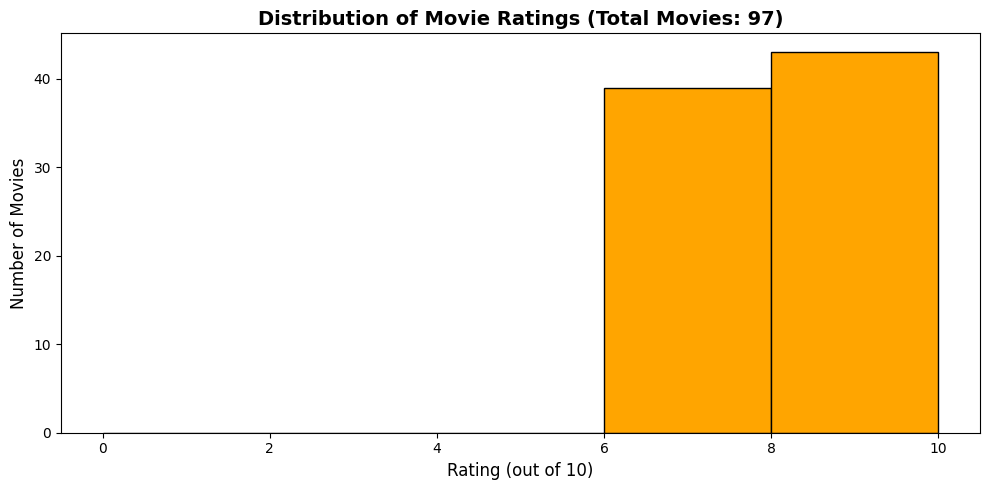

In [16]:
import matplotlib.pyplot as plt

# Count total number of movies
total_num_movies = df['Title'].count()
print("The total number of movies are", total_num_movies)

# Define bins
bins = range(0, 11, 2)

fig, ax = plt.subplots(figsize=(10, 5))

# Plot histogram
ax.hist(df['Rating'],
        bins=bins,
        color='orange',
        edgecolor='black')

# Title and labels
ax.set_title(f'Distribution of Movie Ratings (Total Movies: {total_num_movies})',
             fontsize=14, fontweight='bold')

ax.set_xlabel('Rating (out of 10)', fontsize=12)
ax.set_ylabel('Number of Movies', fontsize=12)

plt.tight_layout()
plt.show()